In [ ]:
# typical python libraries
import numpy as np
import matplotlib.pyplot as plt
import requests

# pytorch libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from huggingface_hub import PyTorchModelHubMixin


# !pip install datasets
# huggingface libraries
from datasets import load_dataset, DatasetDict
from transformers import BertModel, BertTokenizer


In [ ]:
# !pip install datasets
# !pip install "protobuf<5.0.0"

In [ ]:
# import the BERT model and tokenizer
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
cat_ds = load_dataset("albertleigh/az-logic-apps-dataset", data_files="categorization/training_dataset_categorization_v1.parquet")

README.md: 0.00B [00:00, ?B/s]

categorization/training_dataset_categori(…):   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
train_test_split_ds = cat_ds['train'].train_test_split(test_size=0.1)
cat_ds['train'] = train_test_split_ds['train']
cat_ds['test'] = train_test_split_ds['test']

In [ ]:
cat_ds

DatasetDict({
    train: Dataset({
        features: ['expression', 'complete'],
        num_rows: 21159
    })
    test: Dataset({
        features: ['expression', 'complete'],
        num_rows: 2351
    })
})

In [ ]:
longest_expression = ""
max_expression_length = 0
az_lgc_exp_lens= [];
other_exp_lens= [];

for item in cat_ds['train']:
    if (item['complete']):
     az_lgc_exp_lens.append(len(item['expression']))
    else:
      other_exp_lens.append(len(item['expression']))

az_lgc_exp_lens= np.array(az_lgc_exp_lens)
other_exp_lens= np.array(other_exp_lens);

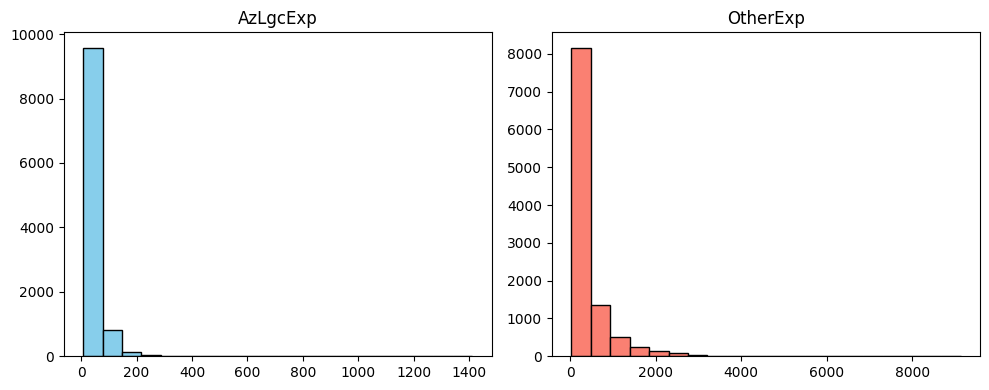

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(az_lgc_exp_lens, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("AzLgcExp")

axes[1].hist(other_exp_lens, bins=20, color='salmon', edgecolor='black')
axes[1].set_title("OtherExp")



plt.tight_layout() # Fixes overlapping labels
plt.show()

In [ ]:
# define a tokenization function that processes each data sample
def tokenize_function(one_sample):
  return tokenizer(
    one_sample['expression'],
    max_length = 512,         # Maximum sequence length
    padding    = 'max_length',# Pad sequences to the maximum length
    truncation = True)        # Truncate sequences longer than max_length


# apply the tokenization function to the dataset (batched for efficiency)
tokenized_dataset = cat_ds.map(tokenize_function, batched=True)

# remove text pair
tokenized_dataset = tokenized_dataset.remove_columns(['expression'])

# change format to pytorch tensors
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'complete'])

# create DataLoaders for training and testing
train_dataloader = DataLoader(tokenized_dataset['train'], shuffle=True, batch_size=32)
test_dataloader  = DataLoader(tokenized_dataset['test'], batch_size=32)

Map:   0%|          | 0/21159 [00:00<?, ? examples/s]

Map:   0%|          | 0/2351 [00:00<?, ? examples/s]

In [ ]:
# check iter
next(iter(train_dataloader))

{'complete': tensor([False, False,  True,  True, False, False, False, False, False,  True,
         False, False, False,  True,  True,  True, False, False, False, False,
         False,  True, False,  True,  True, False,  True,  True,  True,  True,
         False,  True]),
 'input_ids': tensor([[  101,  7276,  4175,  ...,     0,     0,     0],
         [  101,  3853,  1006,  ...,     0,     0,     0],
         [  101,  1030, 19635,  ...,     0,     0,     0],
         ...,
         [  101,  1030,  1063,  ...,     0,     0,     0],
         [  101,  7276, 12105,  ...,     0,     0,     0],
         [  101,  1030,  1063,  ...,     0,     0,     0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]])}

Use pretrained BERT with a new head

In [ ]:
class BertForBinaryClassification(nn.Module,  PyTorchModelHubMixin):
  def __init__(self, num_labels=2):
    super(BertForBinaryClassification, self).__init__()

    # Load the pre-trained BERT model.
    self.bert = BertModel.from_pretrained('bert-base-uncased')
    # self.bert = BertModel.from_pretrained("answerdotai/ModernBERT-base") 8192 windows

    # classification head that converts the 768-d pooled output into 2 final outputs.
    self.classifier = nn.Linear(768,2)
    self.dropout = nn.Dropout(self.bert.embeddings.dropout.p) # 10%

    # initialize the weights and biases
    nn.init.xavier_uniform_(self.classifier.weight)
    nn.init.zeros_(self.classifier.bias)


  def forward(self, input_ids, attention_mask=None, token_type_ids=None):

    # forward pass through the downloaded (pretrained) BERT
    outputs = self.bert(
      input_ids      = input_ids,
      attention_mask = attention_mask,
      token_type_ids = token_type_ids)

    # extract the pooled output and apply dropout
    pooled_output = self.dropout( outputs.pooler_output )

    # final push through the classification layer.
    logits = self.classifier(pooled_output)
    return logits

In [ ]:
# create an instance of the model and test it:
model = BertForBinaryClassification().to(device)
model

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForBinaryClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-1

In [ ]:
## freeze the attention weights
trainParamsCount = 0
frozenParamsCount = 0

for name,param in model.named_parameters():
  if ('attention' in name) or ('embeddings' in name):
    param.requires_grad = False
    frozenParamsCount += torch.numel(param)
    print(f'--- Layer {name} is frozen (.requires_grad = {param.requires_grad}).')

  else:
    param.requires_grad = True # insurance :P
    trainParamsCount += torch.numel(param)
    print(f'+++ Layer {name} is trainable (.requires_grad = {param.requires_grad}).')

print(f'\n\nThere are {frozenParamsCount:,} ({frozenParamsCount*100/(frozenParamsCount+trainParamsCount):.2f}%) frozen weights,')
print(f'      and {trainParamsCount:,} ({trainParamsCount*100/(frozenParamsCount+trainParamsCount):.2f}%) trainable weights.')

--- Layer bert.embeddings.word_embeddings.weight is frozen (.requires_grad = False).
--- Layer bert.embeddings.position_embeddings.weight is frozen (.requires_grad = False).
--- Layer bert.embeddings.token_type_embeddings.weight is frozen (.requires_grad = False).
--- Layer bert.embeddings.LayerNorm.weight is frozen (.requires_grad = False).
--- Layer bert.embeddings.LayerNorm.bias is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.query.weight is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.query.bias is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.key.weight is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.key.bias is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.value.weight is frozen (.requires_grad = False).
--- Layer bert.encoder.layer.0.attention.self.value.bias is frozen (.requires_grad = False).
--- Layer bert.enco

In [ ]:
# training hyperparameters
num_samples = 300

# optimizer and loss function
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-5)
loss_fun = nn.CrossEntropyLoss() # (cross-entropy loss for multi-class classification)

In [ ]:
# initialize performance metrices
train_losses = np.zeros(num_samples)
train_accuracy = np.zeros(num_samples)
test_losses = np.zeros(num_samples)
test_accuracy = np.zeros(num_samples)



## loop over data samples
for sampli in range(num_samples):

  # get a batch of data
  batch = next(iter(train_dataloader))

  # and move it to the GPU
  tokenz  = batch['input_ids'].to(device)
  att_msk = batch['attention_mask'].to(device)
  labels  = batch['complete'].to(device).long()

  # clear the previous gradients
  optimizer.zero_grad()

  # forward pass and get model predictions
  logits = model(tokenz, attention_mask=att_msk)
  predLabels = torch.argmax(logits, dim=1)

  # calculate and store loss + average accuracy
  loss = loss_fun(logits, labels)
  train_losses[sampli] = loss.item()
  train_accuracy[sampli] = (predLabels == labels).sum().item()/train_dataloader.batch_size

  # backward pass
  loss.backward()

  # update the weights and the learning rate
  optimizer.step()

  # test the model and report losses every k samples
  if sampli%10 == 0:

    # evaluation using the test set
    model.eval()
    with torch.no_grad():

      # get a batch of data and move it to the GPU
      batch   = next(iter(test_dataloader))
      tokenz  = batch['input_ids'].to(device)
      att_msk = batch['attention_mask'].to(device)
      labels = batch['complete'].to(device).long()

      # forward pass and get model predictions
      logits = model(tokenz, attention_mask=att_msk)
      predLabels = torch.argmax(logits, dim=1)

      # calculate and store loss + accuracy
      loss = loss_fun(logits, labels.long())
      test_losses[sampli] = loss.item()
      test_accuracy[sampli] = (predLabels == labels).sum().item()/train_dataloader.batch_size

      # report the results
      print(f'Sample {sampli:4}/{num_samples}, losses (train/test): {train_losses[sampli]:.2f}/{test_losses[sampli]:.2f}, accuracy: {train_accuracy[sampli]:.2f}/{test_accuracy[sampli]:.2f}')

      # put the model back into train mode
      model.train()

Sample    0/300, losses (train/test): 0.87/0.67, accuracy: 0.50/0.44
Sample   10/300, losses (train/test): 0.44/0.38, accuracy: 0.94/0.97
Sample   20/300, losses (train/test): 0.27/0.23, accuracy: 0.94/1.00
Sample   30/300, losses (train/test): 0.11/0.11, accuracy: 1.00/1.00
Sample   40/300, losses (train/test): 0.09/0.05, accuracy: 1.00/1.00
Sample   50/300, losses (train/test): 0.04/0.03, accuracy: 1.00/1.00
Sample   60/300, losses (train/test): 0.04/0.02, accuracy: 1.00/1.00
Sample   70/300, losses (train/test): 0.02/0.01, accuracy: 1.00/1.00
Sample   80/300, losses (train/test): 0.02/0.01, accuracy: 1.00/1.00
Sample   90/300, losses (train/test): 0.01/0.01, accuracy: 1.00/1.00
Sample  100/300, losses (train/test): 0.01/0.01, accuracy: 1.00/1.00
Sample  110/300, losses (train/test): 0.01/0.00, accuracy: 1.00/1.00
Sample  120/300, losses (train/test): 0.01/0.00, accuracy: 1.00/1.00
Sample  130/300, losses (train/test): 0.00/0.00, accuracy: 1.00/1.00
Sample  140/300, losses (train/tes

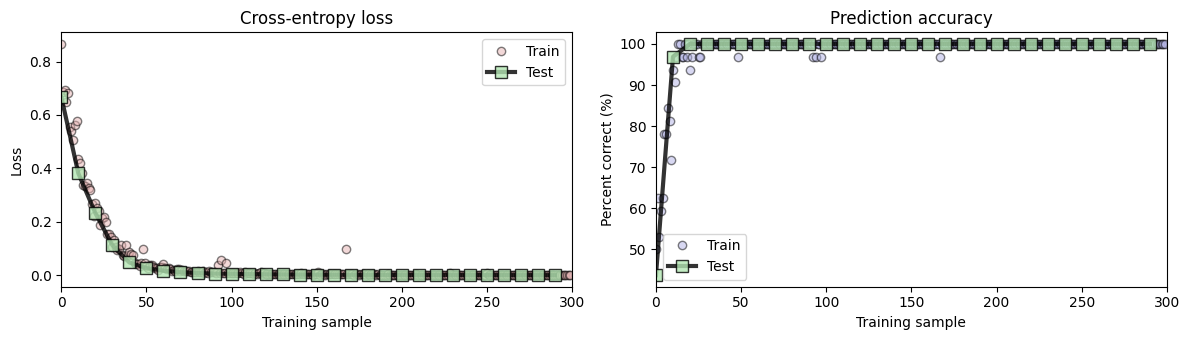

In [ ]:
_,axs = plt.subplots(1,2,figsize=(12,3.5))

# plot the losses
axs[0].plot(train_losses,'ko',markerfacecolor=[.9,.7,.7],alpha=.5,label='Train')
axs[0].plot(range(0,num_samples,10),test_losses[::10],'ks-',
            markerfacecolor=[.7,.9,.7],markersize=8,alpha=.8,linewidth=3,label='Test')
axs[0].set(xlabel='Training sample',ylabel='Loss',title='Cross-entropy loss',xlim=[0,num_samples])
axs[0].legend()

# plot the prediction accuracy
axs[1].plot(100*train_accuracy,'ko',markerfacecolor=[.7,.7,.9],alpha=.5,label='Train')
axs[1].plot(range(0,num_samples,10),100*test_accuracy[::10],'ks-',
            markerfacecolor=[.7,.9,.7],markersize=8,alpha=.8,linewidth=3,label='Test')
axs[1].set(xlabel='Training sample',ylabel='Percent correct (%)',title='Prediction accuracy',xlim=[0,num_samples])
axs[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(),'bert_classifier_azlgcexp_base.pt')
# don't forget to download it :D

In [ ]:
sample = tokenizer( "@{body('Parse_JSON')?['content']?['main_text']}", return_tensors='pt', padding=True, truncation=True).to(device)
# sample = tokenizer( "tokenizer(text, return_tensors='pt', padding=True, truncation=True)", return_tensors='pt', padding=True, truncation=True).to(device)

sampleOutput = model(**sample)

sampleOutput

tensor([[-4.8159,  1.4750]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
# model.load_state_dict(torch.load('bert_classifier_azlgcexp_base.pt'))

In [ ]:
# Save the model and tokenizer to a local directory
model.save_pretrained('./bert_classifier_azlgcexp_base')
tokenizer.save_pretrained('./bert_classifier_azlgcexp_base')

('./bert_classifier_azlgcexp_base/tokenizer_config.json',
 './bert_classifier_azlgcexp_base/special_tokens_map.json',
 './bert_classifier_azlgcexp_base/vocab.txt',
 './bert_classifier_azlgcexp_base/added_tokens.json')

In [ ]:
# Option 3: zip using unix
!zip -r bert_classifier_azlgcexp_base_HF.zip ./bert_classifier_azlgcexp_base

  adding: bert_classifier_azlgcexp_base/ (stored 0%)
  adding: bert_classifier_azlgcexp_base/tokenizer_config.json (deflated 75%)
  adding: bert_classifier_azlgcexp_base/config.json (stored 0%)
  adding: bert_classifier_azlgcexp_base/special_tokens_map.json (deflated 42%)
  adding: bert_classifier_azlgcexp_base/vocab.txt (deflated 53%)
  adding: bert_classifier_azlgcexp_base/README.md (deflated 45%)
  adding: bert_classifier_azlgcexp_base/model.safetensors (deflated 7%)


In [ ]:
from google.colab import files
files.download('bert_classifier_azlgcexp_base_HF.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>